# Respiratory Epidemic Duration

- **Summary**: This document visualizes the duration of threshold-exceeding respiratory viral epidemics.

- **Data Required:** `epidemics_marani_240816.xlsx`

- **Author**: Ganqi Li (ganqi.li.25@dartmouth.edu)
- **Updated**: Sep 10, 2024

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.integrate import quad
from scipy.stats import genpareto
from scipy.optimize import minimize

## repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## 0. Prepare respiratory viral epidemic data

In [45]:
## Read epidemic data from Marani et al. 
df = pd.read_excel("data/epidemics_marani_240816.xlsx")
df = df.sort_values(by='year_start', ascending=True).reset_index(drop=True)

## Subset to respiratory viral epidemics
df_resp_viral = df[df['disease'].isin(['influenza', 'covid-19', 'mers', 'sars'])
                  ].reset_index(drop=True)


In [46]:
## Subset epidemic data to 1600-present
df_resp_viral_marani_inspired = df_resp_viral[(df_resp_viral["year_start"] >= 1600)].reset_index(drop=True)

## Set up severity threshold (SMU)
thresh = 0.01

## Subset to threshold-exceeding respiratory viral epidemics
df_marani_inspired_exceed = df_resp_viral_marani_inspired[df_resp_viral_marani_inspired['severity_smu'] >= thresh].reset_index(drop=True)


In [47]:
## Display
# df_marani_inspired_exceed

In [48]:
## Subset to influenza and coronavirus
df_marani_inspired_flu_exceed = df_marani_inspired_exceed[df_marani_inspired_exceed['disease'] == "influenza"]
df_marani_inspired_cov_exceed = df_marani_inspired_exceed[df_marani_inspired_exceed['disease'] == "covid-19"]

## 1. Visualize duration vs severity

<Figure size 1800x500 with 0 Axes>

Text(1.149636714798124, 2.2, '1781')

Text(0.06974309260051942, 2.2, '1836')

Text(8.748030023773271, 2.2, '1889')

Text(170.8215448673464, 3.2, '1918')

...

(0.01, 1000.0)

(0.0, 7.0)

Text(0.5, 1.0, 'Censored  Durations of Threshold-Exceeding Respiratory Epidemics')

Text(0, 0.5, 'Duration (years)')

Text(0.5, 0, 'Epidemic Severity (SMU or deaths per 10,000 people)')

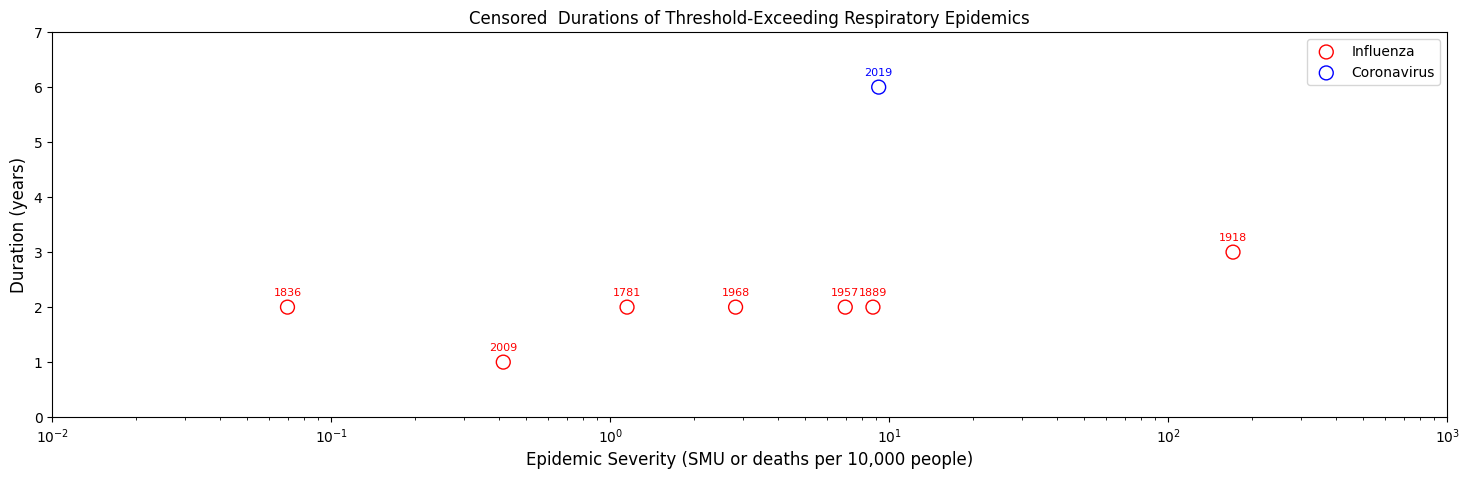

In [49]:
## Set figure size
plt.figure(figsize=(18, 5))

## Plot duration vs severity for influenza epidemics  
plt.scatter(df_marani_inspired_flu_exceed['severity_smu'], 
            df_marani_inspired_flu_exceed['duration'], 
            edgecolor='red', facecolors='none', label='Influenza', s=100)

for i in range(len(df_marani_inspired_flu_exceed)):
    plt.text(df_marani_inspired_flu_exceed['severity_smu'].iloc[i], 
             df_marani_inspired_flu_exceed['duration'].iloc[i] + 0.2,  ## Offset to above circle
             str(df_marani_inspired_flu_exceed['year_start'].iloc[i]), 
             ha='center', 
             fontsize = 8, color = 'red')

    
## Plot duration vs severity for coronavirus epidemics  
plt.scatter(df_marani_inspired_cov_exceed['severity_smu'], 
            df_marani_inspired_cov_exceed['duration'], 
            edgecolor='blue', facecolors='none', label='Coronavirus', s=100)

for i in range(len(df_marani_inspired_cov_exceed)):
    plt.text(df_marani_inspired_cov_exceed['severity_smu'].iloc[i], 
             df_marani_inspired_cov_exceed['duration'].iloc[i] + 0.2,  ## Offset to above circle
             str(df_marani_inspired_cov_exceed['year_start'].iloc[i]), 
             ha='center', 
             fontsize = 8, color = 'blue')

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-2, 1e3)

## Set y-axis limits
plt.ylim(0,7)

## Add title and axes labels
plt.title('Censored  Durations of Threshold-Exceeding Respiratory Epidemics', fontsize = 12)

plt.ylabel('Duration (years)', fontsize = 12)
plt.xlabel('Epidemic Severity (SMU or deaths per 10,000 people)', fontsize = 12)

## Display legend and graph
plt.legend()
plt.show()
